# MES Historical Data Analysis

Generated on 2025-09-24 23:30:10

## Overview
This notebook contains analysis for MES historical data.
The data has been automatically loaded and basic analysis templates are provided.


In [1]:
# Standard imports for financial data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

# Configure plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
# Load data from CSV
csv_path = '..\data\MES_data.csv'
symbol = 'MES'

# Read CSV with proper date parsing
df = pd.read_csv(csv_path)

# Convert date column to datetime
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

# Display basic info
print(f'Loaded {len(df)} rows of data for {symbol}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
df.head()

Loaded 450 rows of data for MES
Date range: 2025-09-24 08:30:00-05:00 to 2025-09-24 15:59:00-05:00


,open,high,low,close,volume
date,,,,,
2025-09-24 08:30:00-05:00,6727.00,6728.5,6723.00,6724.00,7434.0
2025-09-24 08:31:00-05:00,6724.00,6725.5,6722.75,6724.00,4141.0
2025-09-24 08:32:00-05:00,6723.75,6725.0,6722.75,6723.50,2501.0
2025-09-24 08:33:00-05:00,6723.25,6724.0,6721.25,6721.25,3737.0
2025-09-24 08:34:00-05:00,6721.25,6723.5,6719.75,6723.25,5558.0


In [3]:
# Basic data information
print('=== Data Information ===')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print('\n=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Data Information ===
Shape: (450, 5)
Columns: ['open', 'high', 'low', 'close', 'volume']

=== Data Types ===
open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object

=== Missing Values ===
open      0
high      0
low       0
close     0
volume    0
dtype: int64

=== Basic Statistics ===


,open,high,low,close,volume
count,450.000000,450.000000,450.000000,450.000000,450.000000
mean,6697.469444,6698.457778,6696.506111,6697.386667,1876.455556
std,10.919950,10.951053,10.797480,10.830746,1554.855418
min,6678.500000,6680.250000,6678.000000,6678.250000,27.000000
25%,6689.000000,6689.812500,6688.250000,6689.000000,899.500000
50%,6694.000000,6694.875000,6692.750000,6693.875000,1443.000000
75%,6708.500000,6709.250000,6707.437500,6708.250000,2474.750000
max,6727.000000,6728.500000,6723.000000,6724.000000,12090.000000


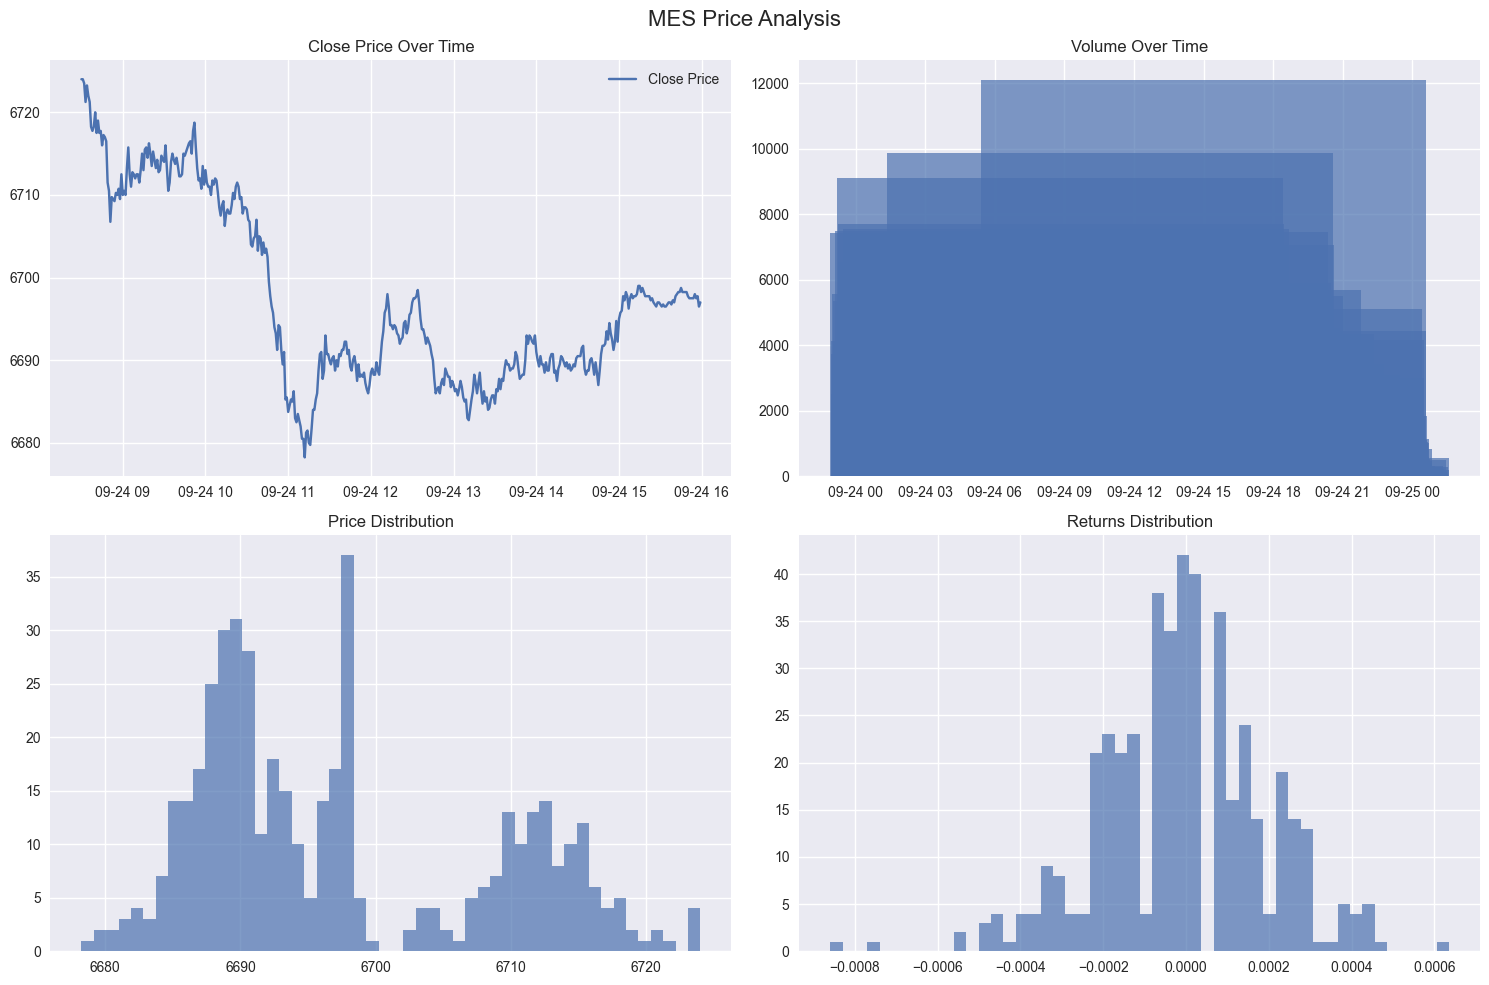

In [4]:
# Basic price visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'{symbol} Price Analysis', fontsize=16)

# Price chart
if 'close' in df.columns:
    axes[0, 0].plot(df.index, df['close'], label='Close Price')
    axes[0, 0].set_title('Close Price Over Time')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

# Volume chart
if 'volume' in df.columns:
    axes[0, 1].bar(df.index, df['volume'], alpha=0.7)
    axes[0, 1].set_title('Volume Over Time')
    axes[0, 1].grid(True)

# Price distribution
if 'close' in df.columns:
    axes[1, 0].hist(df['close'], bins=50, alpha=0.7)
    axes[1, 0].set_title('Price Distribution')
    axes[1, 0].grid(True)

# Returns distribution
if 'close' in df.columns:
    returns = df['close'].pct_change().dropna()
    axes[1, 1].hist(returns, bins=50, alpha=0.7)
    axes[1, 1].set_title('Returns Distribution')
    axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
# Calculate key statistics
if 'close' in df.columns:
    # Price statistics
    current_price = df['close'].iloc[-1]
    price_change = df['close'].iloc[-1] - df['close'].iloc[0]
    price_change_pct = (price_change / df['close'].iloc[0]) * 100
    
    # Returns analysis
    returns = df['close'].pct_change().dropna()
    daily_volatility = returns.std()
    annualized_volatility = daily_volatility * np.sqrt(252)  # Assuming daily data
    
    # Display statistics
    print('=== Key Statistics ===')
    print(f'Current Price: ${current_price:.2f}')
    print(f'Price Change: ${price_change:.2f} ({price_change_pct:.2f}%)')
    print(f'Daily Volatility: {daily_volatility:.4f} ({daily_volatility*100:.2f}%)')
    print(f'Annualized Volatility: {annualized_volatility:.4f} ({annualized_volatility*100:.2f}%)')
    print(f'Max Price: ${df["close"].max():.2f}')
    print(f'Min Price: ${df["close"].min():.2f}')
    
    if 'volume' in df.columns:
        print(f'Average Volume: {df["volume"].mean():,.0f}')
        print(f'Total Volume: {df["volume"].sum():,.0f}')

=== Key Statistics ===
Current Price: $6697.00
Price Change: $-27.00 (-0.40%)
Daily Volatility: 0.0002 (0.02%)
Annualized Volatility: 0.0032 (0.32%)
Max Price: $6724.00
Min Price: $6678.25
Average Volume: 1,876
Total Volume: 844,405


## Further Analysis Templates

### Technical Indicators
```python
# Moving averages
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()

# RSI calculation
def calculate_rsi(prices, window=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = calculate_rsi(df['close'])
```

### Statistical Analysis
```python
# Correlation analysis
correlation_matrix = df[['open', 'high', 'low', 'close', 'volume']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
```

### Risk Metrics
```python
# Value at Risk (VaR)
returns = df['close'].pct_change().dropna()
var_95 = np.percentile(returns, 5)
var_99 = np.percentile(returns, 1)
print(f'VaR (95%): {var_95:.4f}')
print(f'VaR (99%): {var_99:.4f}')
```